In [1]:
import numpy as np 
import pandas as pd 

In [2]:
df=pd.read_csv(r"C:\Users\EXIRIM_Compurer's\Downloads\spam.csv",encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

# **Data Cleaning**


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

In [6]:
df.sample(5)

,v1,v2
3607,ham,Pls come quick cant bare this.
1425,ham,I'll be at mu in like &lt;#&gt; seconds
2444,ham,"Yes but i dont care! I need you bad, princess!"
3539,ham,"I'll get there at 3, unless you guys want me t..."
503,ham,Lolnice. I went from a fish to ..water.?


In [7]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
4727,ham,I (Career Tel) have added u as a contact on IN...
4972,ham,Oops I was in the shower when u called. Hey a ...
1164,ham,Well. Im computerless. Time to make some oreo ...
2744,ham,"Tick, tick, tick ... Babe"
90,ham,Yeah do! DonÛ÷t stand to close tho- youÛ÷ll ...


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder() 


In [9]:
df['target']=encoder.fit_transform(df['target'])

In [10]:
df.sample(5)

,target,text
4062,0,How are you. Its been ages. How's abj
1137,0,LOL ... No just was busy
1679,0,"Today is \song dedicated day..\"" Which song wi..."
4611,0,Sorry da. I gone mad so many pending works wha...
3501,0,I will come to ur home now


In [11]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df.drop_duplicates(keep='first',inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

# **EDA**

In [16]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt 

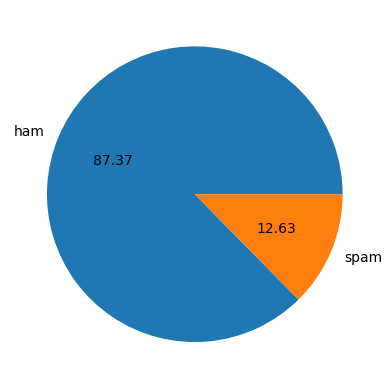

In [18]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [19]:
!pip install nltk

In [20]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\EXIRIM_Compurer's\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
df['num_ch']=df['text'].apply(len)

In [22]:
df.head()

,target,text,num_ch
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\EXIRIM_Compurer's\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\EXIRIM_Compurer's\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df.head()

,target,text,num_ch,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,target,text,num_ch,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['num_ch','num_words','num_sent']].describe()

,num_ch,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
df[df['target']==0][['num_ch','num_words','num_sent']].describe()

,num_ch,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
df[df['target']==1][['num_ch','num_words','num_sent']].describe()

,num_ch,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [31]:
import seaborn as sns

<Axes: xlabel='num_ch', ylabel='Count'>

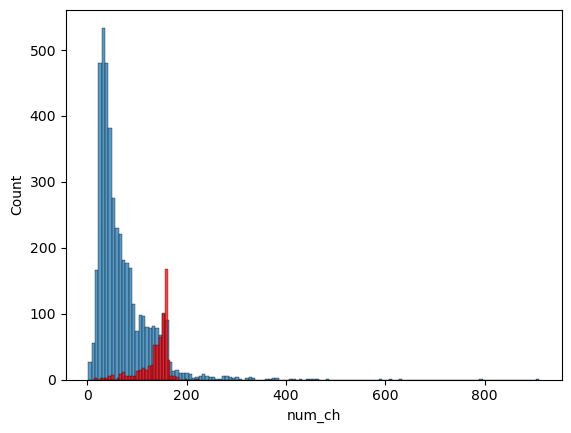

In [32]:
sns.histplot(df[df['target']==0]['num_ch'])
sns.histplot(df[df['target']==1]['num_ch'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

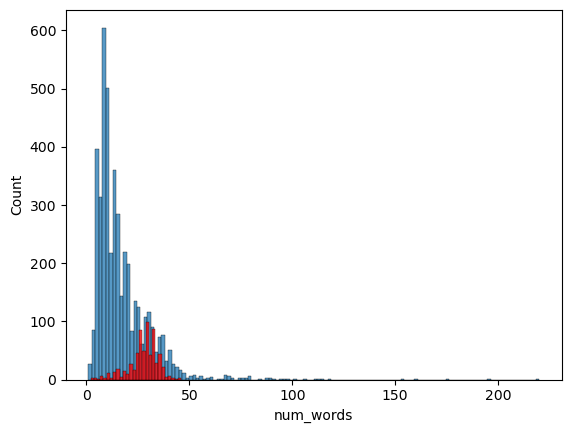

In [33]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

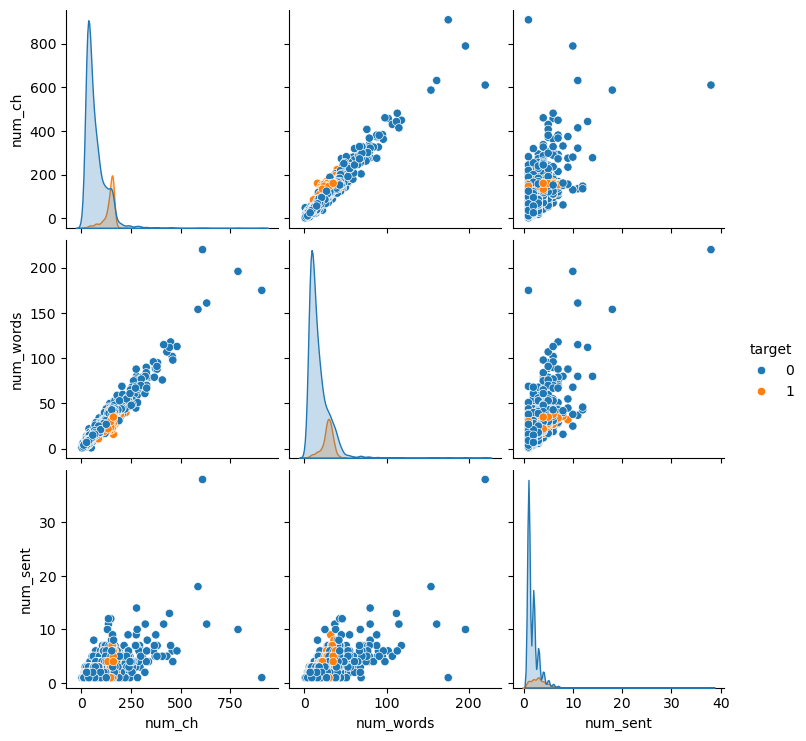

In [34]:
sns.pairplot(df,hue='target')

<Axes: >

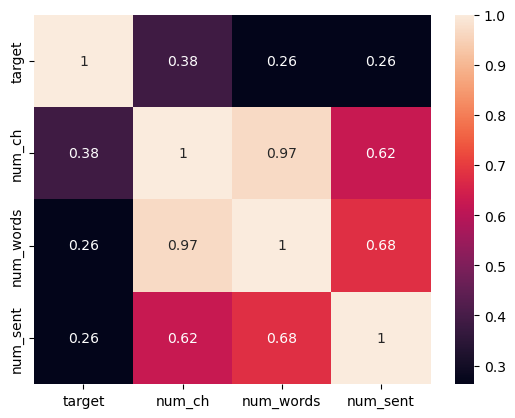

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [36]:
from nltk.stem.porter import PorterStemmer 
ps=PorterStemmer()
ps.stem('loving')

'love'

In [37]:
def transform_text(text): 
    text=text.lower()
    text=nltk.word_tokenize(text)

    
    y=[]
    for i in text: 
        if i.isalnum(): 
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation: 
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [38]:

nltk.download('stopwords')
from nltk.corpus import stopwords 
stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\EXIRIM_Compurer's\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [39]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [40]:
transform_text('Did you liked my tasks on Machine Learning')

'like task machin learn'

In [41]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [42]:
df['transformed_text']=df['text'].apply(transform_text)

In [43]:
df.head()

,target,text,num_ch,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [44]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [45]:
from wordcloud import WordCloud 
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [46]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

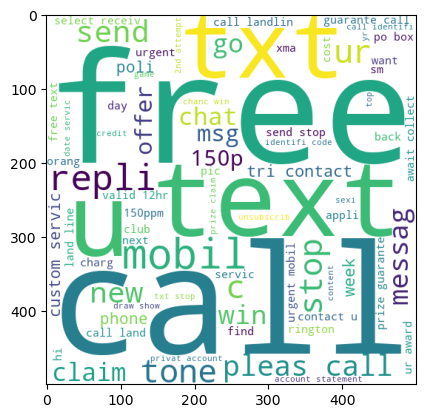

In [47]:
plt.imshow(spam_wc)

In [48]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

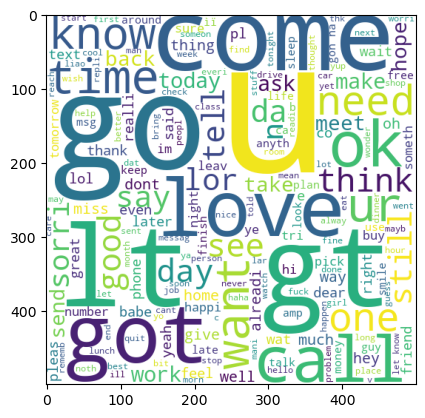

In [49]:
plt.imshow(ham_wc)

In [50]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist(): 
    for words in msg.split():
        spam_corpus.append(words)
        
    

In [51]:
len(spam_corpus)

9939

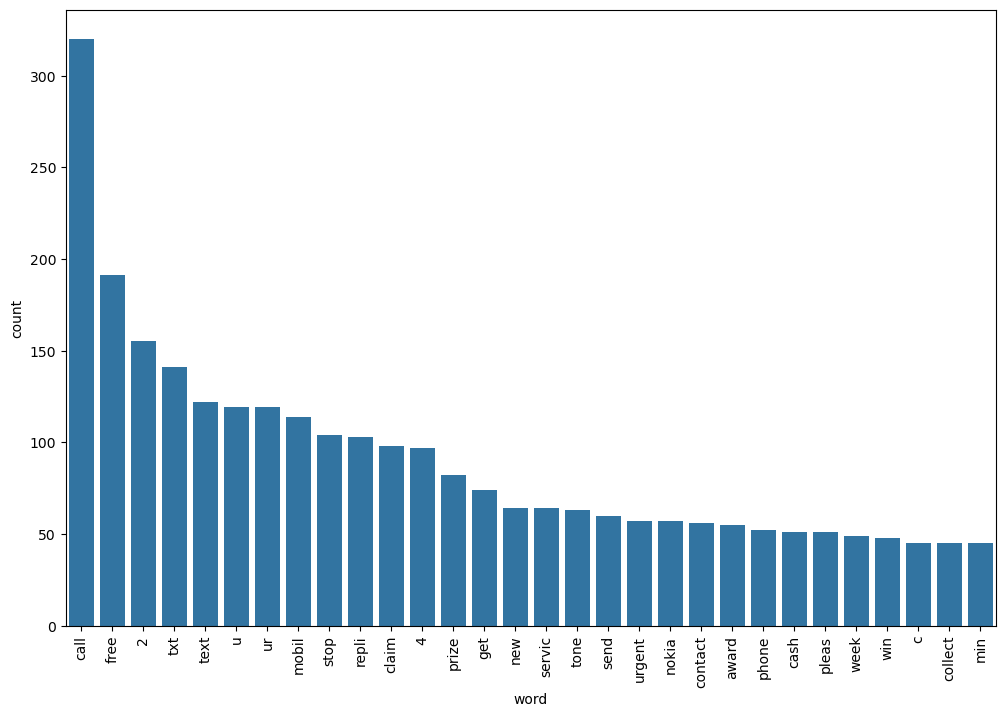

In [52]:
plt.figure(figsize=(12,8))
from collections import Counter 
spam_corpuspd=pd.DataFrame(Counter(spam_corpus).most_common(30),columns=['word','count'])
sns.barplot(x='word',y='count',data=spam_corpuspd)
plt.xticks(rotation='vertical')
plt.show()

In [53]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist(): 
    for words in msg.split():
        ham_corpus.append(words)
        
    

In [54]:
len(ham_corpus)

35404

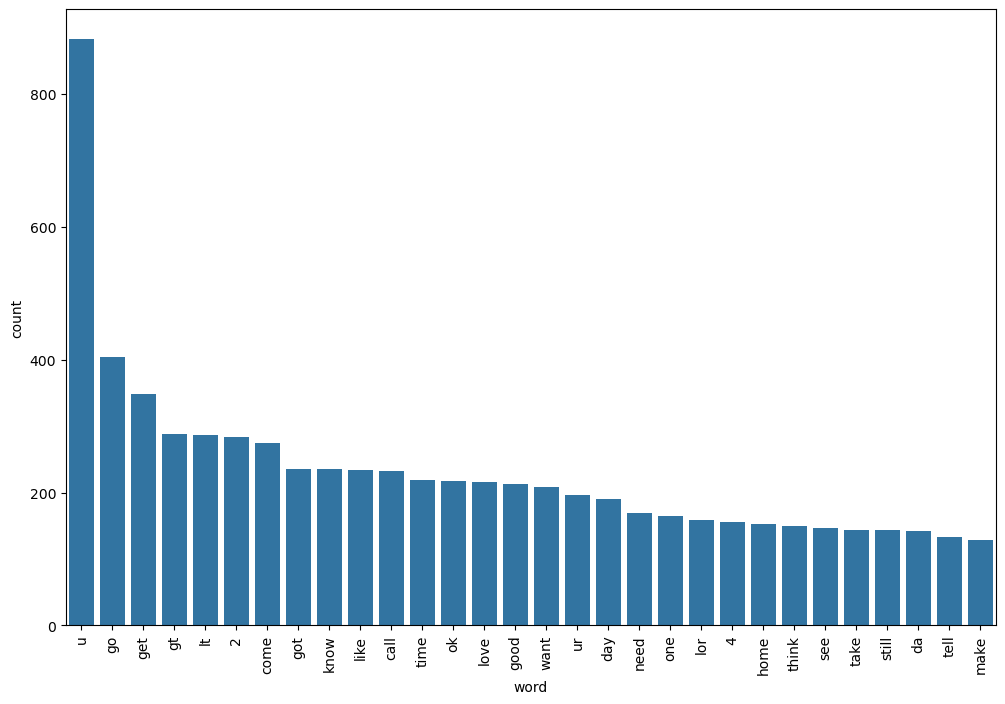

In [55]:
plt.figure(figsize=(12,8))
from collections import Counter 
ham_corpuspd=pd.DataFrame(Counter(ham_corpus).most_common(30),columns=['word','count'])
sns.barplot(x='word',y='count',data=ham_corpuspd)
plt.xticks(rotation='vertical')
plt.show()

In [56]:
df.head()

,target,text,num_ch,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# **Model Building**

In [91]:
from sklearn.feature_extraction.text   import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [92]:
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [113]:
from sklearn.preprocessing import MinMaxScaler 
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

In [94]:
X.shape

(5169, 3000)

In [114]:
y=df['target'].values

In [115]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [116]:
from sklearn.model_selection import train_test_split

In [117]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [118]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [119]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [120]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.8636363636363636
[[768 121]
 [ 20 125]]
0.508130081300813


In [121]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9777562862669246
[[883   6]
 [ 17 128]]
0.9552238805970149


In [122]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))


0.9729206963249516
[[884   5]
 [ 23 122]]
0.9606299212598425


In [123]:
from sklearn.linear_model import LogisticRegression
from  sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 


In [124]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)


In [125]:
clfs={
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc, 
    'RF' : rfc, 
    'AdaBoost': abc, 
   
}

In [126]:
def train_clasifier(clf,X_train,y_train,X_test,y_test): 
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred) 
    precision=precision_score(y_test,y_pred) 

    return accuracy,precision


In [127]:
train_clasifier(svc,X_train,y_train,X_test,y_test)

(0.965183752417795, 0.8920863309352518)

In [128]:
accuracy_scores=[]
precision_scores=[]

for name,clf in clfs.items(): 

    current_accuracy,current_precision=train_clasifier(clf,X_train,y_train,X_test,y_test)

    print("For",name)
    print("Accuracy",current_accuracy)
    print("Precision",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
Accuracy 0.965183752417795
Precision 0.8920863309352518
For KN
Accuracy 0.913926499032882
Precision 1.0
For NB
Accuracy 0.9777562862669246
Precision 0.9552238805970149
For DT
Accuracy 0.9323017408123792
Precision 0.8205128205128205
For LR
Accuracy 0.9622823984526112
Precision 0.9274193548387096
For RF
Accuracy 0.971953578336557
Precision 0.9915254237288136
For AdaBoost
Accuracy 0.913926499032882
Precision 0.7916666666666666


In [129]:
performance_df=pd.DataFrame({"Algorithm" : clfs.keys(),"Accuracy" : accuracy_scores,"Precision":precision_scores})

In [130]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.965184,0.892086
1,KN,0.913926,1.000000
2,NB,0.977756,0.955224
3,DT,0.932302,0.820513
4,LR,0.962282,0.927419
5,RF,0.971954,0.991525
6,AdaBoost,0.913926,0.791667


In [131]:
performance_df1=pd.melt(performance_df,id_vars='Algorithm')
performance_df1

,Algorithm,variable,value
0,SVC,Accuracy,0.965184
1,KN,Accuracy,0.913926
2,NB,Accuracy,0.977756
3,DT,Accuracy,0.932302
4,LR,Accuracy,0.962282
5,RF,Accuracy,0.971954
6,AdaBoost,Accuracy,0.913926
7,SVC,Precision,0.892086
8,KN,Precision,1.000000
9,NB,Precision,0.955224


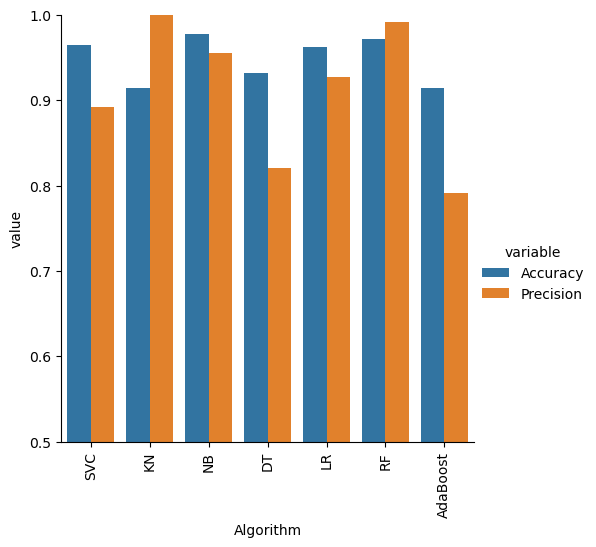

In [132]:
sns.catplot(x='Algorithm',y='value', 
           hue='variable', data=performance_df1,kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [133]:
temp_df=pd.DataFrame({'Algorithm': clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,"Precision_max_ft_3000":precision_scores})

In [134]:
temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.965184,0.892086
1,KN,0.913926,1.000000
2,NB,0.977756,0.955224
3,DT,0.932302,0.820513
4,LR,0.962282,0.927419
5,RF,0.971954,0.991525
6,AdaBoost,0.913926,0.791667


In [135]:
performance_df.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.965184,0.892086,0.965184,0.892086
1,KN,0.913926,1.000000,0.913926,1.000000
2,NB,0.977756,0.955224,0.977756,0.955224
3,DT,0.932302,0.820513,0.932302,0.820513
4,LR,0.962282,0.927419,0.962282,0.927419
5,RF,0.971954,0.991525,0.971954,0.991525
6,AdaBoost,0.913926,0.791667,0.913926,0.791667


In [144]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

In [145]:
voting=VotingClassifier(estimators=[('svm',svc) , ('nb',mnb),('et',etc)],voting='soft')

In [146]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [147]:
y_pred=voting.predict(X_test)
print("accuracy",accuracy_score(y_test,y_pred))
print("precision",precision_score(y_test,y_pred))

accuracy 0.9845261121856866
precision 0.9923664122137404
